In [ ]:
import pandas as pd
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Crear carpeta para guardar modelos
os.makedirs('./entrenamiento', exist_ok=True)

In [5]:
#Leer dataset de entrenamiento
data_path = '../data_sintetica/data_sintetica_sem3.csv'
df = pd.read_csv(data_path)

In [6]:
#Variables
X = df.drop(columns=['transporte'])
y = df['transporte']

In [7]:
#Variables categóricas -> dummies
X_encoded = pd.get_dummies(X, columns=['mineral'], drop_first=True)

In [8]:
X_encoded

,produccion_diaria_tn,tiempo_a_fundicion,tiempo_a_puerto,distancia_total_km,mineral_plomo,mineral_zinc
0,2289,8.24,8.01,317,False,True
1,1925,11.37,15.67,425,False,False
2,956,7.25,10.51,283,False,True
3,2355,3.12,18.47,369,False,True
4,2067,7.05,18.01,390,False,False
...,...,...,...,...,...,...
299995,3841,2.14,16.24,904,False,False
299996,1186,8.31,10.74,932,True,False
299997,3167,8.11,10.55,145,False,False
299998,4055,3.95,8.74,276,True,False


In [9]:
#Escalar características numéricas
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [10]:
X_scaled

array([[-0.35466295,  0.42814068, -1.03566242, -0.89431277, -0.70804037,
         1.41806187],
       [-0.63493765,  1.51236215,  0.73544815, -0.47850572, -0.70804037,
        -0.70518785],
       [-1.38105356,  0.08520801, -0.45762373, -1.025215  , -0.70804037,
         1.41806187],
       ...,
       [ 0.32138429,  0.38310911, -0.44837511, -1.55652401, -0.70804037,
        -0.70518785],
       [ 1.00513138, -1.05790089, -0.86687512, -1.05216545,  1.41234885,
        -0.70518785],
       [-0.45630103,  1.10707808,  1.69036807,  1.17317231,  1.41234885,
        -0.70518785]], shape=(300000, 6))

In [11]:
#Dividir para evaluación
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
X_test.shape

(60000, 6)

In [13]:
# Modleo 1: Árbol de decisión

arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol.fit(X_train, y_train) 
joblib.dump(arbol, './entrenamiento/modelo_arbol.pkl')
print ("Árbol de decisión entrenado y guardado")

Árbol de decisión entrenado y guardado


In [14]:
#Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf, './entrenamiento/modelo_random.pkl')
print("Random forest entrenado y guardado")

Random forest entrenado y guardado


In [15]:
#Guardar scaler para uso de predicción
joblib.dump(scaler, './entrenamiento/scaler.pkl')
print("Scaler guardado")

Scaler guardado


In [16]:
#Evaluar los modelos visualmente
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

Precission Árbol de Decisión 1.00


<function matplotlib.pyplot.show(close=None, block=None)>

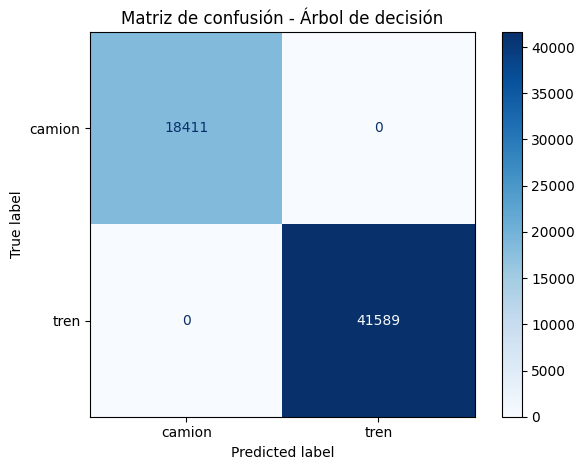

In [17]:
#Evaluación del árbol de decisión
y_pred_arbol = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, y_pred_arbol)
print(f"Precission Árbol de Decisión {acc_arbol:.2f}")

cm_arbol = confusion_matrix(y_test, y_pred_arbol, labels=arbol.classes_)
disp_arbol = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=arbol.classes_)
disp_arbol.plot(cmap='Blues')
plt.title("Matriz de confusión - Árbol de decisión")
plt.tight_layout()
plt.show

Precission Random Forest:1.00


<function matplotlib.pyplot.show(close=None, block=None)>

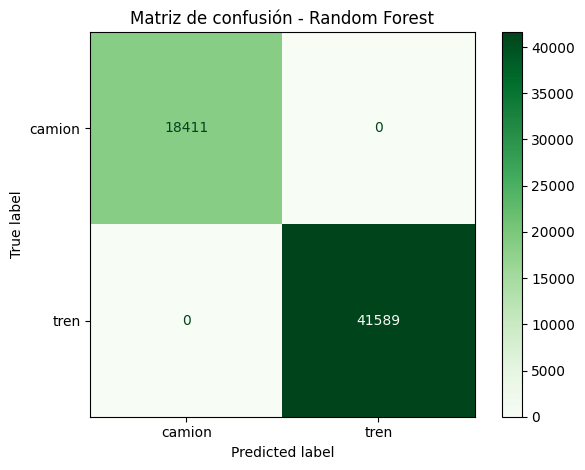

In [18]:
#Evaluación del random forest

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precission Random Forest:{acc_rf:.2f}")

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show